
# The basic idea

The idea is to modelize the system with 3 compartements : A which represents the stomach (we make the approximation that all caffeinated product instantly
gets into the stomach), B represents the circulatory system (so blood) and C represents the metabolites. 
Only the B concentration is plotted, since it's the one that matters the most in term of the project's scope and it's physiological interest. 

We use a simple differential equations system : 
$$
\left\{ \begin{array}{cl}
\frac{dA}{dt} = -K_{01}A(t) \\
\frac{dB}{dt} = K_{01}A_{0}(t) - K_{02}B(t) \\
\frac{dC}{dt} = K_{02}B(t) \\
\end{array} \right.
$$ 

Using Scipy's odeint function, we can plot this B concentration (all source code is to be found in the src folder) : 

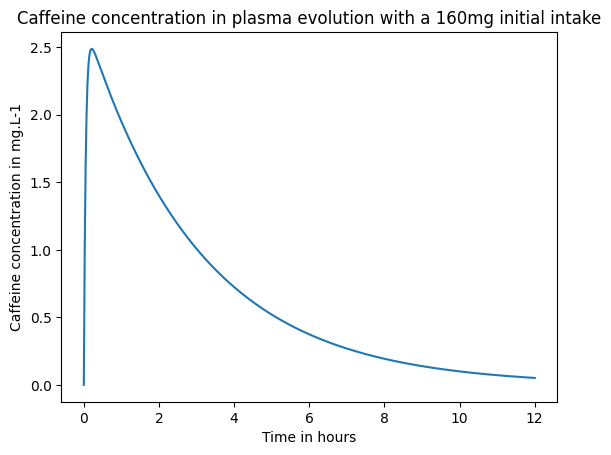

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import odeint

#We have 3 differential equations, with 2 constants :
#The K01 absorption rate constant : 0.33 min^-1
#The K02 elimination rate constant : 0.33 hour^-1 -> 19.8 min^-1 

K01 = 0.33   #minutes-1 
K02 = 0.33*60   #Minutes-1 
QConso = 160 #Quantity in mg

def model(y,t,K01, K02):
    #Parameters
    A,B,C = y 
    #The kinetics equations 
    dydt = [-K01*A, K01*A - K02*B, K02*B]
    return dydt 

y0 = [QConso, 0, 0]
t=np.linspace(0, 12, 1000)
x = odeint(model, y0, t, args=(K01, K02))

B_plot=[]

for i in range(len(x)):
    B_plot.append(x[i][1])

plt.plot(t, B_plot)
plt.title("Caffeine concentration in plasma evolution with a 160mg initial intake")
plt.ylabel("Caffeine concentration in mg.L-1")
plt.xlabel("Time in hours")
plt.show()

Now, let's try and add a second drink. 

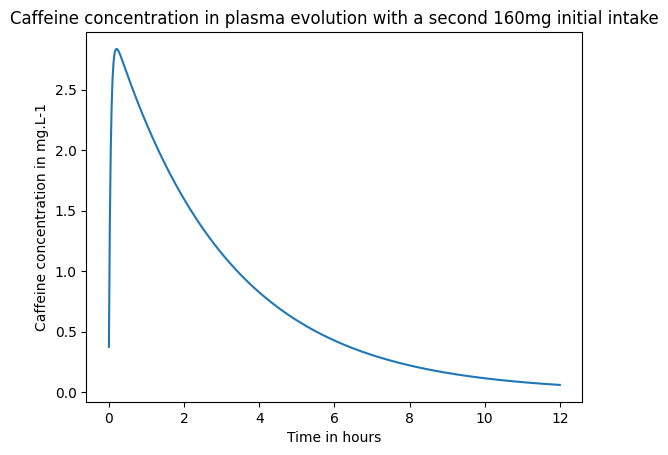

In [3]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import odeint

#We have 3 differential equations, with 2 constants :
#The K01 absorption rate constant : 0.33 min^-1
#The K02 elimination rate constant : 0.33 hour^-1 -> 19.8 min^-1 

K01 = 0.33   #minutes-1 
K02 = 0.33*60   #Minutes-1 
QConso = 160 #Quantity in mg

def model(y,t,K01, K02):
    #Parameters
    A,B,C = y 
    #The kinetics equations 
    dydt = [-K01*A, K01*A - K02*B, K02*B]
    return dydt 

y0 = [QConso, 0, 0]
t=np.linspace(0, 12, 1000)
x = odeint(model, y0, t, args=(K01, K02))

y0 = x[500] + [160, 0, 0]
x = odeint(model, y0, t, args=(K01, K02))

B_plot=[]
for i in range(len(x)):
    B_plot.append(x[i][1])

plt.plot(t, B_plot)
plt.title("Caffeine concentration in plasma evolution with a second 160mg initial intake")
plt.ylabel("Caffeine concentration in mg.L-1")
plt.xlabel("Time in hours")
plt.show()

# Bibliography 

- Standing 2016 : https://doi.org/10.1111/bcp.13119
- Willson 2018 : https://doi.org/10.1016/j.toxrep.2018.11.002
- Alsabri 2018 : https://doi.org/10.1089/caff.2017.0011
- Guide to pharmacology : https://www.guidetopharmacology.org/